# Introduction to Deep Learning — Practical Session

**11 May 2026 · Intro to AI · UZH**

This notebook is designed for a **40-minute final practical session** after the lecture.

In the lecture you saw:

- How a neural network is built (MLP, forward pass)
- How it is trained (gradient descent + backpropagation)
- Why learning rate, overfitting, and architecture choices matter

Now we'll **train one ourselves** and play with the moving parts to feel what actually matters.

We'll use **FashionMNIST** — a small dataset of clothing images (28×28 grayscale, 10 classes: T-shirts, sneakers, dresses, …).

**Core goals for the 40-minute session:**

1. Train your first neural network with PyTorch
2. See how the *learning rate* changes training
3. See what *overfitting* looks like — and how dropout helps

**Bonus, if time remains:** compare an MLP to a CNN on the same task.

> 💡 **How to use this notebook.** Run cells top to bottom. When you see a `# TRY IT` block, change a value and re-run to see what happens. Discuss with the person next to you when prompted.


## Suggested 40-minute flow

| Time | Activity | Main idea |
|---:|---|---|
| 0–5 min | Look at FashionMNIST | What does the model have to learn? |
| 5–15 min | Define the MLP + training loop | Forward pass, loss, backprop, update |
| 15–23 min | Train the first model | `loss.backward()` in action |
| 23–33 min | Learning-rate experiment | Too small / good / too large |
| 33–40 min | Overfitting + dropout | Train loss vs. test loss |

The CNN section at the end is intentionally marked as **bonus**.


## Setup

Run this cell once. It imports everything we need and downloads FashionMNIST (~30 MB, takes a few seconds).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Use GPU if available — much faster
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True,  transform=transform, download=True)
test_dataset  = datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True)

# Official FashionMNIST class order — must match label 0..9 exactly
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

print(f"Training set: {len(train_dataset):>6} images")
print(f"Test set:     {len(test_dataset):>6} images")
print(f"Image shape:  {tuple(train_dataset[0][0].shape)}")
print(f"Classes:      {len(class_names)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 341kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.34MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.2MB/s]

Training set:  60000 images
Test set:      10000 images
Image shape:  (1, 28, 28)
Classes:      10


## 1. Look at the data

Let's see what we're working with.

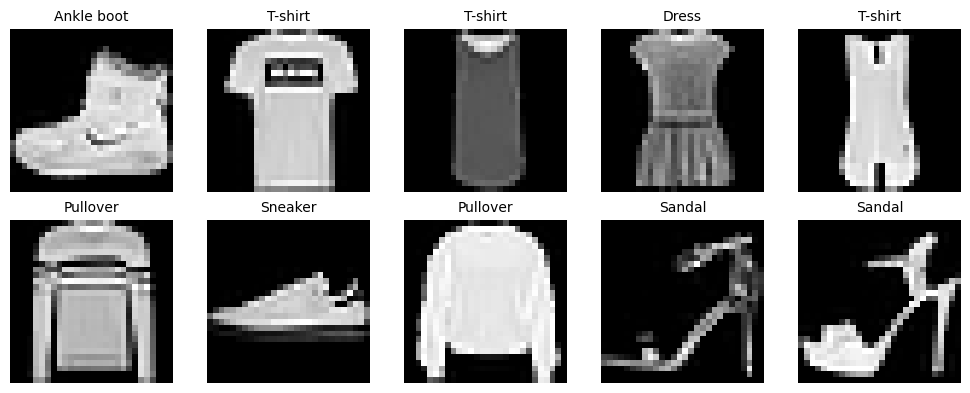

In [4]:
# First 10 samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # Cast label to int — torchvision may return numpy/torch scalar
    # depending on version, which would break list indexing.
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[int(label)], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

**Quick reflection.** Compare a *T-shirt* and a *Pullover*. Some pairs of classes are clearly harder to tell apart than others. A good neural network should figure out *which features* distinguish them — without us telling it.

This is the **representation learning** idea from the lecture: we don't hand-craft "sleeve length" or "neckline shape" — the network learns them from data, end-to-end.

## 2. Your first neural network

Let's define a simple **MLP** — exactly the architecture we drew on the board.

Our model:

- **Input:** 28×28 = 784 numbers (flattened pixels)
- **Hidden layer 1:** 128 neurons, ReLU activation
- **Hidden layer 2:** 64 neurons, ReLU activation
- **Output:** 10 numbers (one logit per class)

Three matrix multiplications and two activations. That's it.

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[128, 64], num_classes=10, dropout=0.0):
        super().__init__()
        layers = []
        prev = 28 * 28
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten 28x28 -> 784
        return self.net(x)


# Quick sanity check
model = MLP().to(device)
x_sample, _ = train_dataset[0]
x_sample = x_sample.unsqueeze(0).to(device)
out = model(x_sample)

print(f"Input shape:       {tuple(x_sample.shape)}")
print(f"Output shape:      {tuple(out.shape)}    (one score per class)")
print(f"Total parameters:  {sum(p.numel() for p in model.parameters()):,}")

Input shape:       (1, 1, 28, 28)
Output shape:      (1, 10)    (one score per class)
Total parameters:  109,386


### The training loop

This is the **gradient descent + backpropagation** loop you saw in Block 2 — written in PyTorch.

The key three lines:

- `optimizer.zero_grad()` — clear old gradients
- `loss.backward()` — backpropagation: compute every gradient, automatically
- `optimizer.step()` — gradient descent update: $w \leftarrow w - \eta \cdot \nabla L$

You did it by hand for a tiny 1-1-1 network. PyTorch does it for any network, in microseconds.

> *Note on terminology:* `torch.optim.SGD` with a DataLoader of `batch_size=64` is **mini-batch SGD** (Slide 38). The PyTorch class is just named "SGD" for short — we follow that convention below.

In [7]:
def train_model(model, train_loader, test_loader, lr=0.01, epochs=3, verbose=True):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_losses, test_accs = [], [], []

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        epoch_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()    # clear old gradients
            out = model(x)            # forward pass
            loss = criterion(out, y)
            loss.backward()           # backpropagation
            optimizer.step()          # w <- w - lr * grad
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # ---- Evaluation ----
        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                test_loss += criterion(out, y).item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        test_losses.append(test_loss / len(test_loader))
        test_accs.append(correct / total)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"train_loss={train_losses[-1]:.3f} | "
                  f"test_loss={test_losses[-1]:.3f} | "
                  f"test_acc={test_accs[-1]:.3f}")

    return train_losses, test_losses, test_accs


def plot_curves(curves_dict, title=""):
    """curves_dict: {label: (train_losses, test_losses)}"""
    plt.figure(figsize=(9, 4))
    for label, (train_l, test_l) in curves_dict.items():
        epochs = range(1, len(train_l) + 1)
        plt.plot(epochs, train_l, '-o', label=f"{label} (train)")
        plt.plot(epochs, test_l, '--s', label=f"{label} (test)")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Train it!

We'll use a small subset (5000 train, 1000 test) so that everything runs quickly — even without a GPU. The story is exactly the same on the full dataset.

For the first run, we use `lr=0.05` with SGD. This is usually more visible than a very tiny learning rate within only 5 epochs.

Training...

Epoch 1/5 | train_loss=1.463 | test_loss=1.075 | test_acc=0.550
Epoch 2/5 | train_loss=0.746 | test_loss=0.886 | test_acc=0.674
Epoch 3/5 | train_loss=0.640 | test_loss=0.688 | test_acc=0.722
Epoch 4/5 | train_loss=0.574 | test_loss=1.137 | test_acc=0.643
Epoch 5/5 | train_loss=0.530 | test_loss=0.586 | test_acc=0.789


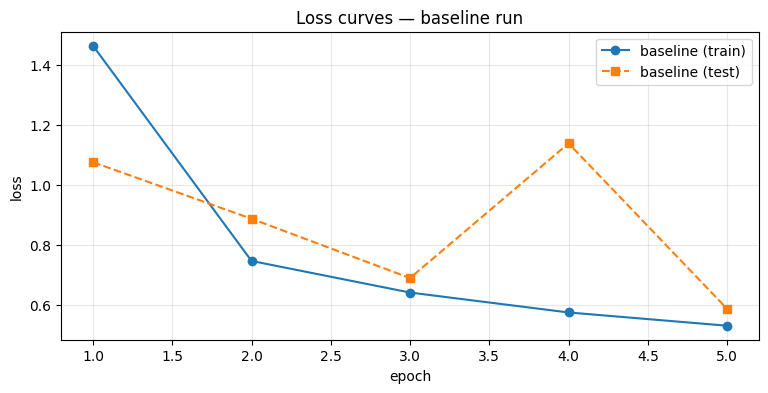

In [8]:
# Manageable subset so things run quickly
train_subset = Subset(train_dataset, range(5000))
test_subset  = Subset(test_dataset,  range(1000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_subset,  batch_size=128)

# Fresh model
model = MLP().to(device)

print("Training...\n")
train_l, test_l, test_a = train_model(model, train_loader, test_loader,
                                       lr=0.05, epochs=5)
plot_curves({"baseline": (train_l, test_l)},
            title="Loss curves — baseline run")

**You just trained a neural network!**

A 109,000-parameter network has learned to classify clothing images, all driven by `loss.backward()` doing exactly what you did by hand in the lecture.

A few things to notice:

- Train loss should decrease fairly steadily over epochs if the learning rate is reasonable.
- Test loss generally follows train loss down, but can be **bumpy from one epoch to the next** — that's normal with a small dataset and mini-batch SGD.
- The exact numbers vary by machine and random seed, but you should already see meaningful learning (test accuracy well above the 10% random-guess baseline) after only a few epochs.

Now let's see what happens when we change the moving parts.

## 3. The learning rate experiment

> Recall the lecture slide: one curve converges smoothly, one is too slow, and one oscillates or diverges.

Before running the next cell, predict what will happen:

- Which learning rate will be **too small**?
- Which one will be **reasonable**?
- Which one may become **unstable**?

Then run the cell and compare your prediction with the curves.


--- Training with lr=0.001 ---
Epoch 1/5 | train_loss=2.296 | test_loss=2.290 | test_acc=0.167
Epoch 2/5 | train_loss=2.271 | test_loss=2.266 | test_acc=0.211
Epoch 3/5 | train_loss=2.244 | test_loss=2.240 | test_acc=0.220
Epoch 4/5 | train_loss=2.216 | test_loss=2.212 | test_acc=0.221
Epoch 5/5 | train_loss=2.185 | test_loss=2.182 | test_acc=0.248

--- Training with lr=0.1 ---
Epoch 1/5 | train_loss=1.196 | test_loss=1.073 | test_acc=0.612
Epoch 2/5 | train_loss=0.678 | test_loss=1.367 | test_acc=0.568
Epoch 3/5 | train_loss=0.586 | test_loss=0.788 | test_acc=0.713
Epoch 4/5 | train_loss=0.528 | test_loss=1.512 | test_acc=0.577
Epoch 5/5 | train_loss=0.502 | test_loss=0.819 | test_acc=0.688

--- Training with lr=1.0 ---
Epoch 1/5 | train_loss=2.386 | test_loss=2.334 | test_acc=0.123
Epoch 2/5 | train_loss=2.228 | test_loss=38.569 | test_acc=0.095
Epoch 3/5 | train_loss=3.949 | test_loss=2.313 | test_acc=0.171
Epoch 4/5 | train_loss=2.161 | test_loss=2.550 | test_acc=0.104
Epoch 5/5 |

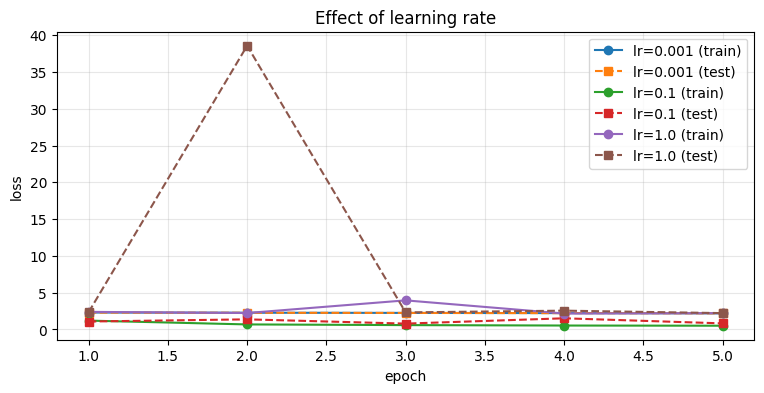

In [9]:
lrs = [0.001, 0.1, 1.0]
results = {}

for lr in lrs:
    print(f"\n--- Training with lr={lr} ---")
    model = MLP().to(device)
    train_l, test_l, _ = train_model(
        model, train_loader, test_loader, lr=lr, epochs=5, verbose=True)
    results[f"lr={lr}"] = (train_l, test_l)

plot_curves(results, title="Effect of learning rate")

**Notice the three regimes:**

- `lr=0.001` (too small): loss barely moves — train and test loss decrease very slowly, accuracy stays near random. With *much* more time you'd get there, but you're wasting compute.
- `lr=0.1` (fast but borderline): train loss drops quickly — even faster than the baseline `lr=0.05` — but **test loss bounces around** from epoch to epoch. Each step is big enough to make solid progress *and* big enough to occasionally overshoot, so the test curve is jagged and the final test accuracy can actually end up *worse* than the calmer baseline.
- `lr=1.0` (too large): the step size is so big that GD overshoots wildly. Loss jumps around or blows up (test loss can spike into the tens), and accuracy is near random.

Same picture as the lecture slide — but with real data instead of a sketch. The sweet spot isn't a single number; it's a *range*, and the boundary between "fast" and "unstable" is fuzzy.

**Takeaway.** Learning rate is one of the most important hyperparameters. In practice people try several values and pick the best on a validation set. Adaptive optimizers like Adam help, but they don't free you from caring.

> **Think.** What about `lr=0.03` or `lr=0.3`? Predict the loss curve before you run, then check.

Epoch 1/5 | train_loss=1.571 | test_loss=1.167 | test_acc=0.503
Epoch 2/5 | train_loss=0.802 | test_loss=0.792 | test_acc=0.715
Epoch 3/5 | train_loss=0.653 | test_loss=0.821 | test_acc=0.687
Epoch 4/5 | train_loss=0.597 | test_loss=0.804 | test_acc=0.710
Epoch 5/5 | train_loss=0.560 | test_loss=0.833 | test_acc=0.642


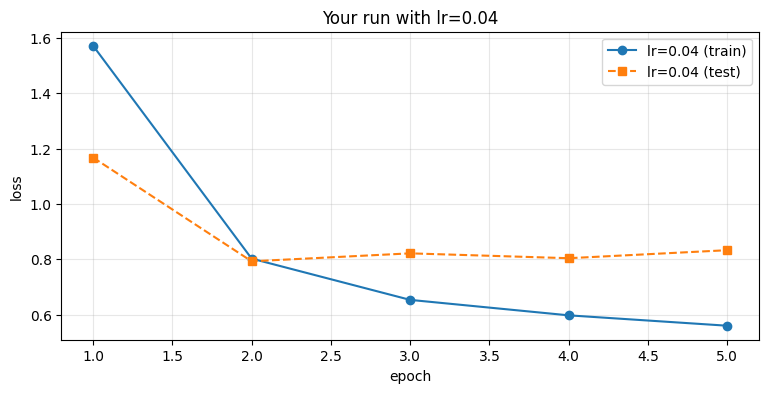

In [11]:
# TRY IT — pick a learning rate and predict what the loss curve will look like.
my_lr = 0.04   # change me!

model = MLP().to(device)
train_l, test_l, _ = train_model(model, train_loader, test_loader,
                                  lr=my_lr, epochs=5)
plot_curves({f"lr={my_lr}": (train_l, test_l)},
            title=f"Your run with lr={my_lr}")

## 4. Watch overfitting happen

In the lecture we said deep networks have so many parameters they can **memorize** the training data — and then fail on new data. Let's see this in action.

Recipe for overfitting:

- **Lots of parameters** (a big model relative to the data)
- **Little data** (we'll use just 500 training images)
- **Enough epochs and a reasonable learning rate** so the network actually has time to memorize

With these knobs set right, the train/test gap is usually clearly visible.

Parameters:        300,938
Training samples:      500
-> 602x more parameters than data points



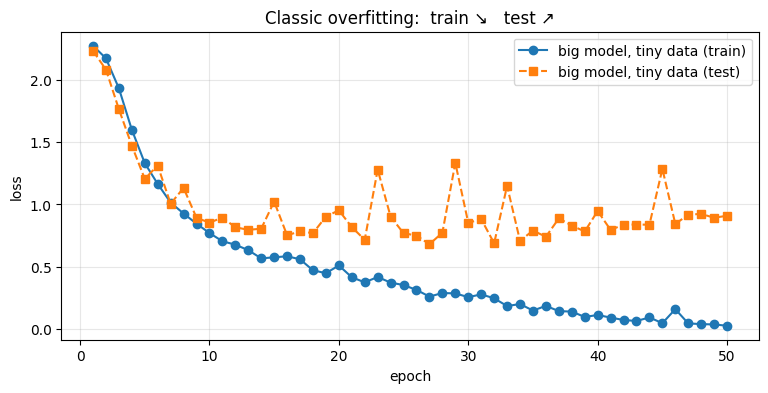

In [12]:
# Tiny dataset — easy to memorize.
# 500 samples / batch_size 32 ≈ 16 mini-batches per epoch, which is enough
# gradient steps per epoch to actually drive training loss down.
tiny_train = Subset(train_dataset, range(500))
tiny_train_loader = DataLoader(tiny_train, batch_size=32, shuffle=True)

# Large model relative to the data, but not so huge that lr=0.05 becomes unstable.
big_model = MLP(hidden_sizes=[256, 256, 128]).to(device)
n_params = sum(p.numel() for p in big_model.parameters())

print(f"Parameters:        {n_params:>7,}")
print(f"Training samples:  {len(tiny_train):>7,}")
print(f"-> {n_params / len(tiny_train):.0f}x more parameters than data points\n")

# Use the same "reasonable" learning rate as the baseline, and train long
# enough that memorization clearly kicks in. 50 epochs makes the train/test
# gap unmistakable on this tiny dataset.
train_l, test_l, _ = train_model(
    big_model, tiny_train_loader, test_loader,
    lr=0.05, epochs=50, verbose=False)

plot_curves({"big model, tiny data": (train_l, test_l)},
            title="Classic overfitting:  train ↘   test ↗")

**Look at the gap.**

Training loss usually keeps going down — the model is fitting the 500 training images.
But test loss may stop improving or start **rising**. The model is learning patterns that do not generalize well.

This shape (train loss decreasing, test loss stalling or rising) is one of the most important diagnostics in deep learning. Whenever you see it, you have an overfitting problem.

### Now let's fix it with dropout

In Block 3 we listed three remedies: **weight decay**, **dropout**, **early stopping**. Let's try dropout — randomly zero out neurons during training so the network can't rely too heavily on any single one.

Before running the next cell, predict: will dropout make the **training** loss lower or higher? What about the **test** loss?

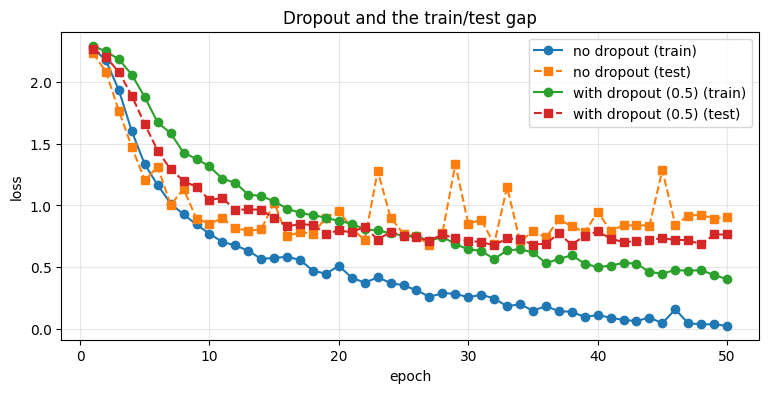

In [13]:
# Same architecture, but with dropout = 0.5.
# Light dropout (e.g. 0.1) is often too weak to make a visible difference on
# a strongly-overfitting setup — 0.5 is a more standard "noticeable" value.

big_model_dropout = MLP(hidden_sizes=[256, 256, 128], dropout=0.5).to(device)

train_l_dr, test_l_dr, _ = train_model(
    big_model_dropout, tiny_train_loader, test_loader,
    lr=0.05, epochs=50, verbose=False)

plot_curves({
    "no dropout":          (train_l,    test_l),
    "with dropout (0.5)":  (train_l_dr, test_l_dr),
}, title="Dropout and the train/test gap")

**The gap shrinks.**

Dropout doesn't make the *training* loss go lower — actually it goes a bit higher, because the model can't memorize as easily. But the **test** loss is lower, and that's what we care about.

The training loss measures how well we fit the past. The test loss measures how well we'll do on the future.

> **Try.** What about `dropout = 0.1`? Or `0.7`? Where does dropout become *too weak* or *too much*?

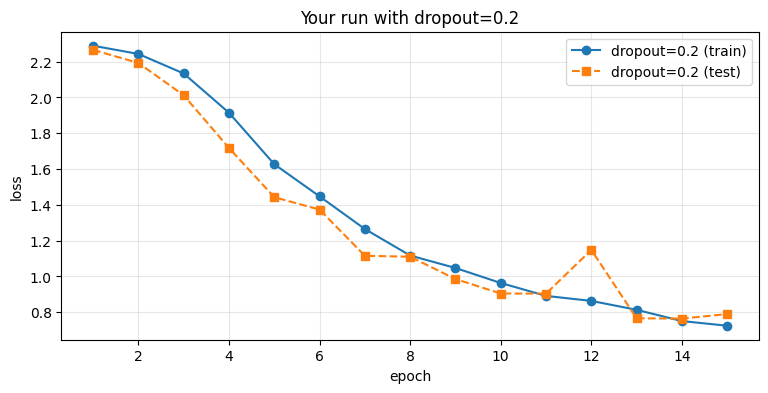

In [15]:
# OPTIONAL TRY IT — pick a dropout rate.
my_dropout = 0.2   # change me

model = MLP(hidden_sizes=[256, 256, 128], dropout=my_dropout).to(device)
train_l, test_l, _ = train_model(model, tiny_train_loader, test_loader,
                                  lr=0.05, epochs=15, verbose=False)
plot_curves({f"dropout={my_dropout}": (train_l, test_l)},
            title=f"Your run with dropout={my_dropout}")

## 5. Bonus / self-study: CNN vs MLP

This section connects to Block 3's final message: **architecture matters.**

For the 40-minute class, this part is optional. You can either:

- briefly show the code and explain the idea, or
- leave it as self-study.

We'll train a small CNN on the same task. The inductive bias built into convolutions (weight sharing, locality, translation equivariance) gives it a head start over the MLP.

CNN parameters:   20,490
MLP parameters:  109,386

--- MLP ---
Epoch 1/5 | train_loss=1.538 | test_loss=0.979 | test_acc=0.621
Epoch 2/5 | train_loss=0.766 | test_loss=1.386 | test_acc=0.574
Epoch 3/5 | train_loss=0.655 | test_loss=1.360 | test_acc=0.555
Epoch 4/5 | train_loss=0.579 | test_loss=0.822 | test_acc=0.682
Epoch 5/5 | train_loss=0.545 | test_loss=0.760 | test_acc=0.735

--- CNN ---
Epoch 1/5 | train_loss=1.307 | test_loss=1.145 | test_acc=0.659
Epoch 2/5 | train_loss=0.723 | test_loss=0.958 | test_acc=0.665
Epoch 3/5 | train_loss=0.583 | test_loss=0.987 | test_acc=0.731
Epoch 4/5 | train_loss=0.530 | test_loss=0.557 | test_acc=0.802
Epoch 5/5 | train_loss=0.470 | test_loss=0.776 | test_acc=0.696

Final test accuracy
  MLP: 73.5%
  CNN: 69.6%


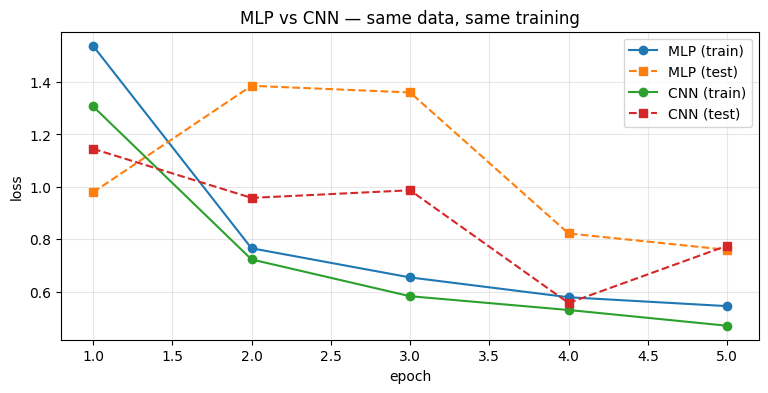

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc    = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)         # 28 -> 14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)         # 14 -> 7
        x = x.view(x.size(0), -1)
        return self.fc(x)


# Compare parameter counts
cnn = SimpleCNN().to(device)
mlp = MLP().to(device)
print(f"CNN parameters:  {sum(p.numel() for p in cnn.parameters()):>7,}")
print(f"MLP parameters:  {sum(p.numel() for p in mlp.parameters()):>7,}\n")

# Same data, same hyperparameters — only architecture differs
print("--- MLP ---")
mlp_train_l, mlp_test_l, mlp_test_a = train_model(
    mlp, train_loader, test_loader, lr=0.05, epochs=5)

print("\n--- CNN ---")
cnn_train_l, cnn_test_l, cnn_test_a = train_model(
    cnn, train_loader, test_loader, lr=0.05, epochs=5)

print(f"\nFinal test accuracy")
print(f"  MLP: {mlp_test_a[-1]*100:.1f}%")
print(f"  CNN: {cnn_test_a[-1]*100:.1f}%")

plot_curves({
    "MLP": (mlp_train_l, mlp_test_l),
    "CNN": (cnn_train_l, cnn_test_l),
}, title="MLP vs CNN — same data, same training")

**The CNN does better — with about 5× fewer parameters.**

In this run the CNN (\~20k parameters) reaches higher final test accuracy than the MLP (\~109k parameters), using the same data, same optimizer, and same number of epochs.

Convolutions hard-code two assumptions:

- **Locality** — nearby pixels matter together
- **Translation equivariance** — a feature detector should work the same anywhere in the image (this is what weight sharing buys you)

**Same backprop. Same gradient descent. Different architecture → different result.**

## Wrap-up

You've now experienced the central story of the lecture as a working, running thing.

**What you saw in the 40-minute core session:**

1. **Backpropagation works.** Your MLP learned from data through `loss.backward()`.
2. **Learning rate matters a lot.** Too small wastes compute, too large can diverge.
3. **Overfitting is visible.** Train loss and test loss can tell different stories.
4. **Regularization helps.** Dropout can reduce reliance on memorized patterns.

**Bonus idea:** architecture matters. Same optimizer, same data — a CNN can do better than an MLP because it encodes useful assumptions about images.

**Where to go next:**

- Try the **Adam** optimizer instead of SGD: `torch.optim.Adam(model.parameters(), lr=0.001)` — usually much more forgiving.
- Run on the **full dataset** (change `range(5000)` → `range(60000)`). With a GPU runtime in Colab this is just minutes.
- Try **CIFAR-10** (10 classes of 32×32 *colour* images): swap `datasets.FashionMNIST` for `datasets.CIFAR10`. Effect of CNN might be stronger.


The whole field of modern deep learning sits on top of what you saw today. Same backprop, same gradient descent. Just much, much bigger.

🎉 **Have fun!**